In [ ]:
import pandas as pd

op = pd.read_csv('op_1_0.csv')
ip = pd.read_csv('ip_1_0.csv')
surgery = pd.read_csv('Total_surgeries_1_0.csv')
lab = pd.read_csv('lab_investigation_0.csv')

print("=== OUTPATIENTS ===")
print(op.head())
print(op.shape)

print("\n=== INPATIENTS ===")
print(ip.head())
print(ip.shape)

print("\n=== SURGERIES ===")
print(surgery.head())
print(surgery.shape)

print("\n=== LAB INVESTIGATIONS ===")
print(lab.head())
print(lab.shape)





=== OUTPATIENTS ===
  S. No                                Institution Name       2013       2014  \
0     1  Rajiv Gandhi Govt. General Hospital, Chennai 3  2702566.0  2791065.0   
1     2                  Govt Stanley Hospital, Chennai  2056720.0  2097409.0   
2     3           Govt Kilpauk Medical College Hospital   844077.0   840055.0   
3     4           Chengalpattu Medical College Hospital  1169962.0  1109754.0   
4     5              Thanjavur Medical College Hospital  1141168.0  1139562.0   

        2015       2016       2017  
0  2747363.0  2936104.0  2750290.0  
1  2297357.0  2434812.0  3479817.0  
2   884702.0   976317.0  1085369.0  
3  1166155.0  1144448.0  1168507.0  
4  1117473.0   837939.0   828404.0  
(60, 7)

=== INPATIENTS ===
  S.No                           Institution Name      2013      2014  \
0    1       Rajiv Gandhi Govt. General Hospital.  874023.0  890566.0   
1    2             Govt Stanley Hospital, Chennai  437446.0  455428.0   
2    3  Govt Kilpauk Med

In [ ]:
op.columns = op.columns.str.strip()
ip.columns = ip.columns.str.strip()
surgery.columns = surgery.columns.str.strip()
lab.columns = lab.columns.str.strip()

op = op.rename(columns={'Institution Name': 'Institution_Name'})
ip = ip.rename(columns={'Institution Name': 'Institution_Name'})
surgery = surgery.rename(columns={'Institution Name': 'Institution_Name'})
lab = lab.rename(columns={'Institution  Name': 'Institution_Name'})

def clean_df(df):
    df = df[df['Institution_Name'].str.lower() != 'grand total']
    df = df.replace('NA', 0)
    df = df.replace('Nil', 0)
    for col in ['2013', '2014', '2015', '2016', '2017']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df = df.reset_index(drop=True)
    return df

op = clean_df(op)
ip = clean_df(ip)
surgery = clean_df(surgery)
lab = clean_df(lab)

print("Cleaning done! ")
print("Outpatients:", op.shape)
print("Inpatients:", ip.shape)
print("Surgeries:", surgery.shape)
print("Lab:", lab.shape)

Cleaning done! 
Outpatients: (59, 7)
Inpatients: (45, 7)
Surgeries: (41, 7)
Lab: (48, 7)


In [ ]:
op['Total'] = op[['2013','2014','2015','2016','2017']].sum(axis=1)
ip['Total'] = ip[['2013','2014','2015','2016','2017']].sum(axis=1)
surgery['Total'] = surgery[['2013','2014','2015','2016','2017']].sum(axis=1)
lab['Total'] = lab[['2013','2014','2015','2016','2017']].sum(axis=1)

op['Growth%'] = ((op['2017'] - op['2013']) / op['2013'] * 100).round(1)
ip['Growth%'] = ((ip['2017'] - ip['2013']) / ip['2013'] * 100).round(1)
surgery['Growth%'] = ((surgery['2017'] - surgery['2013']) / surgery['2013'] * 100).round(1)
lab['Growth%'] = ((lab['2017'] - lab['2013']) / lab['2013'] * 100).round(1)

print("New columns added! ")
print(op[['Institution_Name','Total','Growth%']].head())

New columns added! 
                                 Institution_Name       Total  Growth%
0  Rajiv Gandhi Govt. General Hospital, Chennai 3  13927388.0      1.8
1                  Govt Stanley Hospital, Chennai  12366115.0     69.2
2           Govt Kilpauk Medical College Hospital   4630520.0     28.6
3           Chengalpattu Medical College Hospital   5758826.0     -0.1
4              Thanjavur Medical College Hospital   5064546.0    -27.4


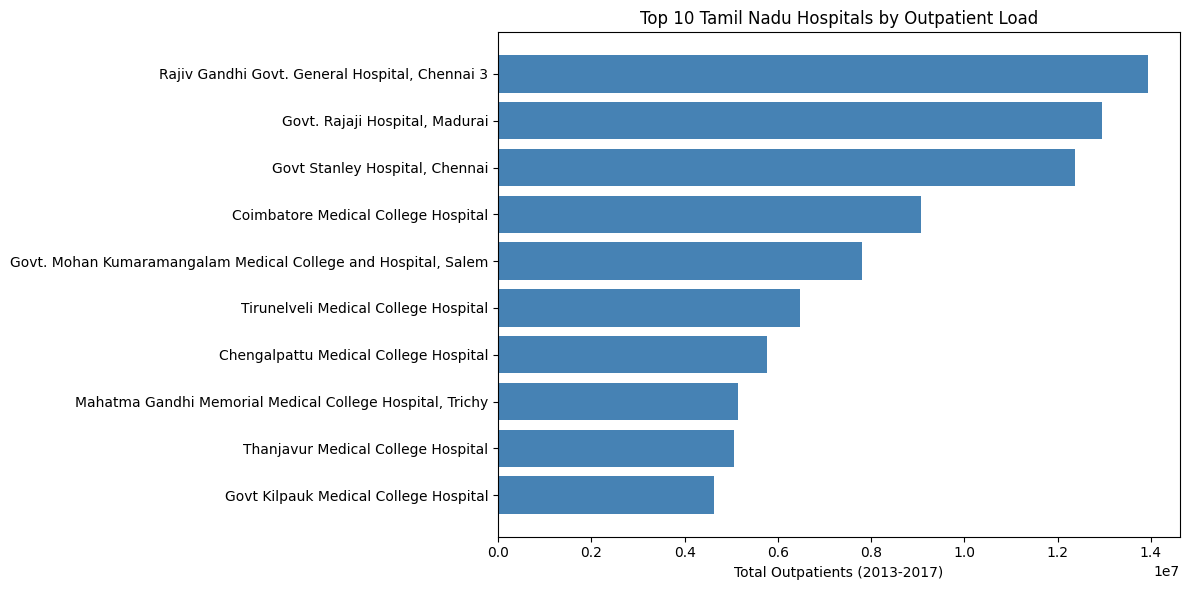

Chart 1 done! 


In [ ]:
import matplotlib.pyplot as plt

top_op = op.nlargest(10, 'Total')

plt.figure(figsize=(12,6))
plt.barh(top_op['Institution_Name'], top_op['Total'], color='steelblue')
plt.xlabel('Total Outpatients (2013-2017)')
plt.title('Top 10 Tamil Nadu Hospitals by Outpatient Load')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart1_top_outpatients.png')
plt.show()
print("Chart 1 done! ")

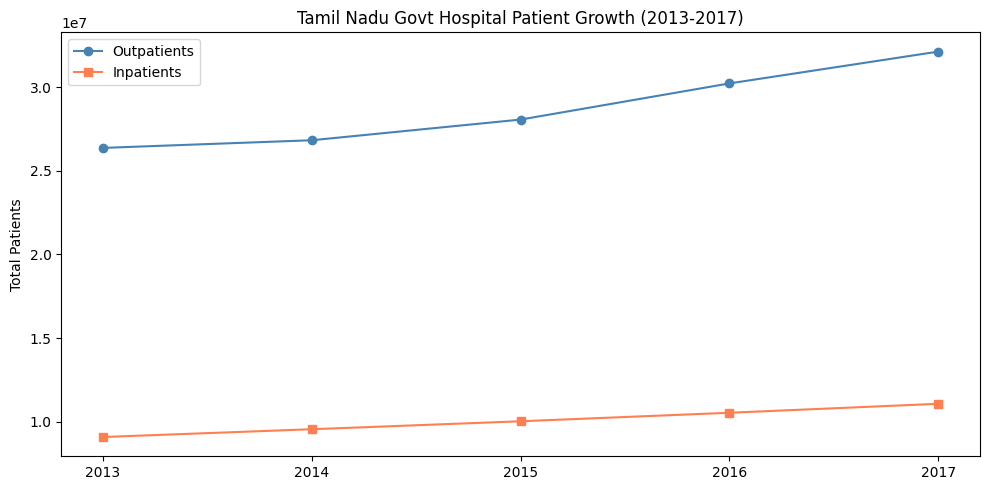

Chart 2 done! 


In [ ]:
years = ['2013','2014','2015','2016','2017']
op_totals = [op[y].sum() for y in years]
ip_totals = [ip[y].sum() for y in years]

plt.figure(figsize=(10,5))
plt.plot(years, op_totals, marker='o', label='Outpatients', color='steelblue')
plt.plot(years, ip_totals, marker='s', label='Inpatients', color='coral')
plt.title('Tamil Nadu Govt Hospital Patient Growth (2013-2017)')
plt.ylabel('Total Patients')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_growth_trend.png')
plt.show()
print("Chart 2 done! ")

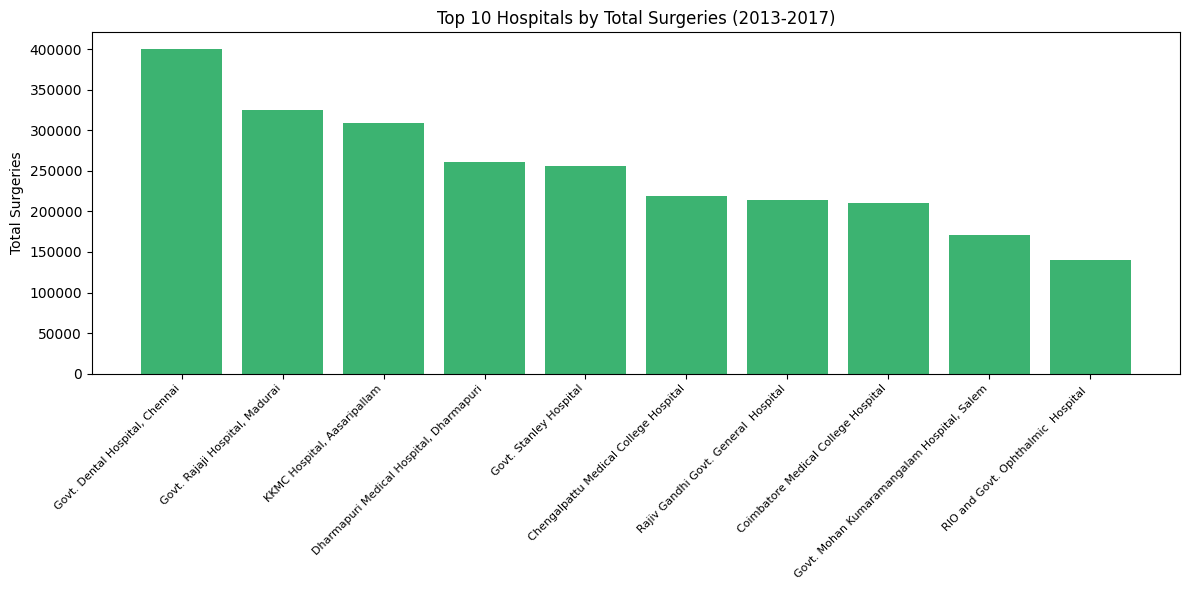

In [ ]:
top_surg = surgery.nlargest(10, 'Total')
plt.figure(figsize=(12,6))
plt.bar(top_surg['Institution_Name'], top_surg['Total'], color='mediumseagreen')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Top 10 Hospitals by Total Surgeries (2013-2017)')
plt.ylabel('Total Surgeries')
plt.tight_layout()
plt.savefig('chart3_surgeries.png')
plt.show()

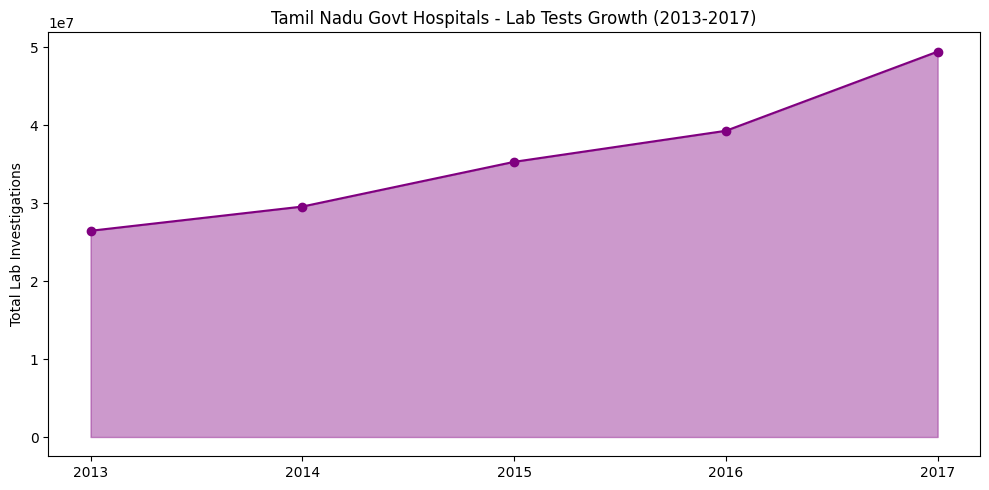

Charts 3 & 4 done! 


In [ ]:
lab_totals = [lab[y].sum() for y in ['2013','2014','2015','2016','2017']]

plt.figure(figsize=(10,5))
plt.fill_between(years, lab_totals, alpha=0.4, color='purple')
plt.plot(years, lab_totals, marker='o', color='purple')
plt.title('Tamil Nadu Govt Hospitals - Lab Tests Growth (2013-2017)')
plt.ylabel('Total Lab Investigations')
plt.tight_layout()
plt.savefig('chart4_lab_growth.png')
plt.show()
print("Charts 3 & 4 done! ")

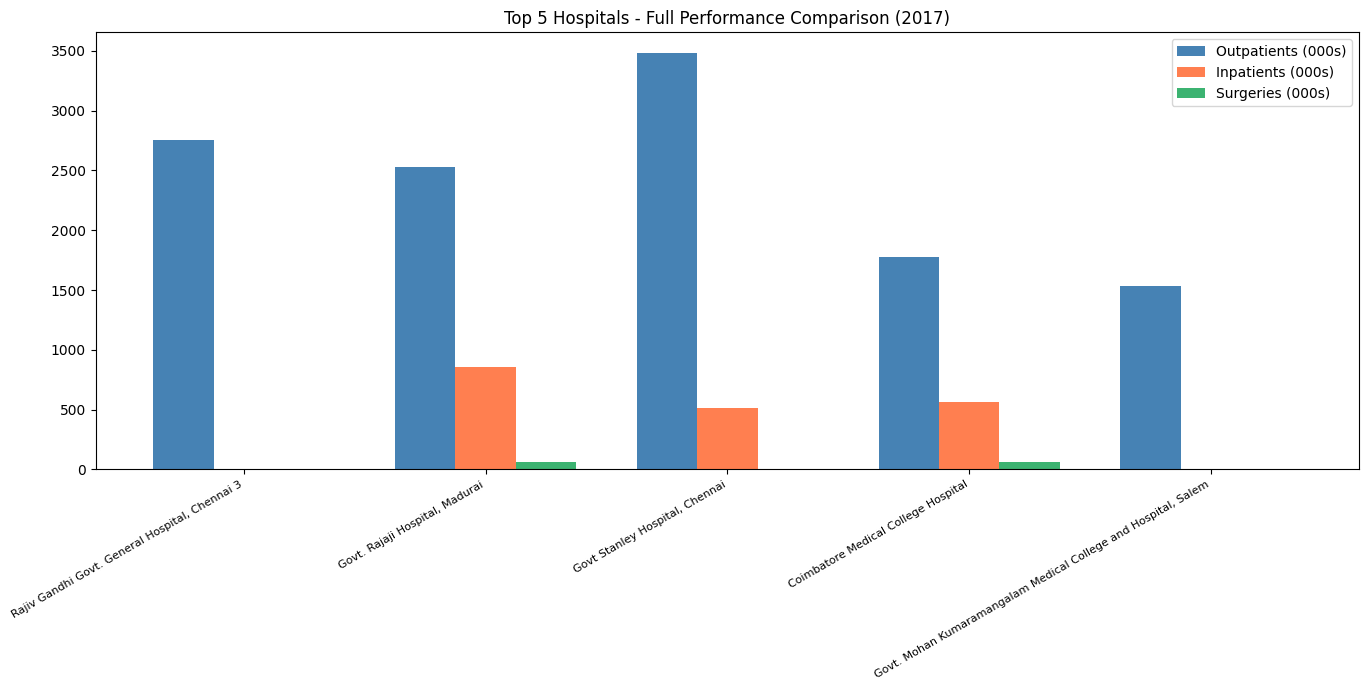

Chart 5 done! 


In [ ]:
top5 = op.nlargest(5, 'Total')['Institution_Name'].tolist()

# Get 2017 values for each metric for these 5 hospitals
op_vals = op[op['Institution_Name'].isin(top5)].set_index('Institution_Name')['2017']
ip_vals = ip[ip['Institution_Name'].isin(top5)].set_index('Institution_Name')['2017']
surg_vals = surgery[surgery['Institution_Name'].isin(top5)].set_index('Institution_Name')['2017']

import numpy as np
x = np.arange(len(top5))
width = 0.25

fig, ax = plt.subplots(figsize=(14,7))
ax.bar(x - width, op_vals.reindex(top5).fillna(0)/1000, width, label='Outpatients (000s)', color='steelblue')
ax.bar(x, ip_vals.reindex(top5).fillna(0)/1000, width, label='Inpatients (000s)', color='coral')
ax.bar(x + width, surg_vals.reindex(top5).fillna(0)/1000, width, label='Surgeries (000s)', color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(top5, rotation=30, ha='right', fontsize=8)
ax.set_title('Top 5 Hospitals - Full Performance Comparison (2017)')
ax.legend()
plt.tight_layout()
plt.savefig('chart5_comparison.png')
plt.show()
print("Chart 5 done! ")

In [ ]:
import sqlite3

conn = sqlite3.connect(':memory:')

op.to_sql('outpatients', con=conn, if_exists='replace', index=False)
ip.to_sql('inpatients', con=conn, if_exists='replace', index=False)
surgery.to_sql('surgeries', con=conn, if_exists='replace', index=False)
lab.to_sql('lab_investigations', con=conn, if_exists='replace', index=False)

print("Done! ")

Done! 


In [ ]:
query1 = '''
SELECT Institution_Name, "2017" as Outpatients_2017
FROM outpatients
ORDER BY "2017" DESC
LIMIT 5
'''
result1 = pd.read_sql_query(query1, conn)
print("=== Top 5 Hospitals by Outpatients (2017) ===")
print(result1)


=== Top 5 Hospitals by Outpatients (2017) ===
                                    Institution_Name  Outpatients_2017
0                     Govt Stanley Hospital, Chennai         3479817.0
1     Rajiv Gandhi Govt. General Hospital, Chennai 3         2750290.0
2                     Govt. Rajaji Hospital, Madurai         2530783.0
3                Coimbatore Medical College Hospital         1779626.0
4  Govt. Mohan Kumaramangalam Medical College and...         1533574.0


In [ ]:
query2 = '''
SELECT
    SUM("2013") as Total_2013,
    SUM("2017") as Total_2017,
    ROUND((SUM("2017") - SUM("2013")) * 100.0 / SUM("2013"), 2) as Growth_Percent
FROM outpatients
'''
result2 = pd.read_sql_query(query2, conn)
print("\n=== Tamil Nadu Outpatient Growth 2013 to 2017 ===")
print(result2)


=== Tamil Nadu Outpatient Growth 2013 to 2017 ===
   Total_2013  Total_2017  Growth_Percent
0  26363686.0  32114994.0           21.82


In [ ]:
query3 = '''
SELECT Institution_Name, "2017" as Surgeries_2017
FROM surgeries
ORDER BY "2017" DESC
LIMIT 5
'''
result3 = pd.read_sql_query(query3, conn)
print("\n=== Top 5 Hospitals by Surgeries (2017) ===")
print(result3)


=== Top 5 Hospitals by Surgeries (2017) ===
                        Institution_Name  Surgeries_2017
0            KKMC Hospital, Aasaripallam         76023.0
1         Govt. Dental Hospital, Chennai         75756.0
2    Coimbatore Medical College Hospital         65757.0
3  Chengalpattu Medical College Hospital         62528.0
4         Govt. Rajaji Hospital, Madurai         62135.0


In [ ]:
query4 = '''
SELECT Institution_Name,
    "2013" as Start_2013,
    "2017" as End_2017,
    ROUND(("2017" - "2013") * 100.0 / "2013", 2) as Growth_Percent
FROM inpatients
WHERE "2013" > 0 AND "2017" > 0
ORDER BY Growth_Percent ASC
LIMIT 5
'''
result4 = pd.read_sql_query(query4, conn)
print("=== Hospitals with Lowest/Negative Inpatient Growth ===")
print(result4)

=== Hospitals with Lowest/Negative Inpatient Growth ===
                                    Institution_Name  Start_2013  End_2017  \
0  Govt. Institute of Rehab Medical KK Nagar, Che...     28247.0     11705   
1            Govt. Hospital, Balarangapuram, Madurai     13643.0      6284   
2               Govt. Peripheral Hospital, K.K.Nagar     14852.0      8679   
3        Govt Hospital of Thoracic Medical, Tambaram    254813.0    177620   
4  Arignar Anna Memorial Cancer Hospital, Karapet...     80340.0     56435   

   Growth_Percent  
0          -58.56  
1          -53.94  
2          -41.56  
3          -30.29  
4          -29.75  


In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd
from google.colab import files

with pd.ExcelWriter('TamilNadu_Healthcare_Summary.xlsx', engine='openpyxl') as writer:
    op.to_excel(writer, sheet_name='Outpatients', index=False)
    ip.to_excel(writer, sheet_name='Inpatients', index=False)
    surgery.to_excel(writer, sheet_name='Surgeries', index=False)
    lab.to_excel(writer, sheet_name='Lab_Investigations', index=False)

print("Excel file created!")

Excel file created!


In [ ]:
from google.colab import files
files.download('TamilNadu_Healthcare_Summary.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>